---
authors:
  - name: Tom Siegl
---

# How to Find $\hat{\beta}$ & Projections in $\mathbb{R}^n$

## How to Find $\hat{\beta}$

:::{note} Matrix Notation of $x$ and $y$
:class:dropdown simple
We consider a matrix $\mathbf{X}$ of $n \times p$ variables:

$$
\mathbf{X} = \begin{bmatrix}
x_{11} && x_{12} && \cdots && x_{1p} \\
x_{21} && x_{22} && \cdots && x_{2p} \\
\vdots && \vdots && \ddots && \vdots \\
x_{n1} && x_{n2} && \cdots && x_{np}
\end{bmatrix}
= \begin{bmatrix}
\mid && \mid &&  && \mid \\
\mathbf{x}_1 && \mathbf{x}_2 && \cdots && \mathbf{x}_p \\
\mid && \mid &&  && \mid
\end{bmatrix}
$$

and a vector $\mathbf{y}$ of $n$ variables:

$$
\mathbf{y} = \begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
$$
:::

We can write the RSS in matrix notation as

$$RSS(\beta) = (\mathbf{y} - \mathbf{X}\beta)^T (\mathbf{y} - \mathbf{X}\beta).$$

The minimum of this function is the $\beta$, that results in the smallest overall distance of the model predictions to the actual target values.

The gradient of this function is

$$\nabla_{\beta}{RSS(\beta)} = \mathbf{X}^T(\mathbf{y} - \mathbf{X}\beta).$$

The RSS is optimal where its gradient is zero ([Hastie et al., 2009](https://doi.org/10.1007/978-0-387-84858-7)):

$$\mathbf{X}^T(\mathbf{y} - \mathbf{X}\hat{\beta}) = \mathbf{0}$$

With a quick rearrangement for $\hat{\beta}$, we find the ordinary least squares (OLS) solution to the optimization problem of minimizing $RSS(\beta)$:

$$(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y} = \hat{\beta}$$

:::{important} Tasks
1. Bonus: Rearrange $\mathbf{X}^T(\mathbf{y} - \mathbf{X}\hat{\beta}) = \mathbf{0}$ to obtain the solution for $\hat{\beta}$. (The dropdown "Rearrangement steps" below has the solution.)
:::

:::{tip} Your answer
:class:dropdown
1. 
:::

## Projections in $\mathbb{R}^n$

Let's put the prediction target aside and just think about the underlying geometry of the OLS solution to $\beta$ for a moment.
(In the prediction setting, this only corresponds to the training/fitting process.)

The lecture has presented a special orthogonal projection of a vector $\mathbf{y} \in \mathbb{R}^n$:

$$\hat{\mathbf{y}} = \mathbf{X} (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

We will now dissect this projection to reveal the intuition behind it.

### A Single Dimension

The full projection can be very hard to comprehend since there are so many numbers involved, which are arranged into variably many columns and rows of different matrices.

To reduce complexity, let's first have a look at the projection when $p=1$. This allows us to simplify the projection to get:

$$\hat{\mathbf{y}} = \mathbf{x}_1 \frac{\textcolor{red}{\mathbf{x}_1 \cdot \mathbf{y}}}{||\mathbf{x}_1||^2}$$

:::{important} Tasks
1. Bonus: Simplify the equation for $\hat{\mathbf{y}}$ for the case $p=1$, such that the result is only expressed in terms of vectors and vector operations. (The dropdown "Simplification steps" below has the solution.)
:::

:::{tip} Your answer
:class:dropdown
1. 
:::

Seems kind of familiar, right?
You have implemented the $\textcolor{red}{\text{red}}$ part of this formula in the PCA exercise as the orthogonal projection of a point onto a (potential) principal component!
(There we have avoided the division by the length of the projection vector by restricting the length of that vector to $1$.
The final multiplication by the projection vector was hidden in the supplied plotting code.)

Let's visualize this projection for some example values.

In [1]:
################################
# RUN, THEN COLLAPSE THIS CELL #
################################

import numpy as np
import matplotlib.pyplot as plt


def orthogonal_projection(x_1, y):
    return x_1 * (np.dot(x_1, y) / (np.linalg.norm(x_1)**2))


def plot_vector(v, name, ax, shift=[0, 0], color="black"):
    perpendicular = np.array([-v[1], v[0]]) / np.linalg.norm(v)
    ax.annotate("", xytext=(shift[0], shift[1]), xy=(shift[0]+v[0], shift[1]+v[1]), arrowprops=dict(arrowstyle="->", color=color), zorder=30)
    ax.text(shift[0]+(v[0]/2) + perpendicular[0]*0.02, shift[1]+(v[1]/2) + perpendicular[1]*0.02, name, color=color,
        horizontalalignment="center", verticalalignment="center")


def plot_projection_2d(x_1, y, ax):
    # get projection
    y_proj = orthogonal_projection(x_1, y)

    # show gridlines
    ax.grid(zorder=0)

    # show vectors
    plot_vector(y, r"$\mathbf{y}$", ax, color="red")
    plot_vector(y_proj, r"$\hat{\mathbf{y}}$", ax, shift=[0., 0.02], color="red")
    plot_vector(y-y_proj, r"$\mathbf{e}$", ax, shift=y_proj, color="gray")
    plot_vector(x_1, r"$\mathbf{x}_1$", ax, color="blue")
    
    # set axis limits
    all_content = np.zeros((2*x_1.shape[0] + 1, 2))
    all_content[:x_1.shape[0]] = x_1
    all_content[x_1.shape[0]:2*x_1.shape[0]] = y_proj
    all_content[-1] = y
    xlim = [all_content[:, 0].min(), all_content[:, 0].max()]
    ylim = [all_content[:, 1].min(), all_content[:, 1].max()]
    padding = min([0.5, 0.2*(xlim[1]-xlim[0]), 0.2*(ylim[1]-ylim[0])])
    xlim[0] -= padding
    xlim[1] += padding
    ylim[0] -= padding
    ylim[1] += padding
    xlim[0] = min(xlim[0], ylim[0], 0)
    xlim[1] = max(xlim[1], ylim[1])
    ylim[0] = min(xlim[0], ylim[0], 0)
    ylim[1] = max(xlim[1], ylim[1])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # define annotations
    ax.set_title(r"Projection of $\mathbf{y}$ onto $\mathbf{x}_1$")
    ax.set_xlabel("Observation 1")
    ax.set_ylabel("Observation 2")

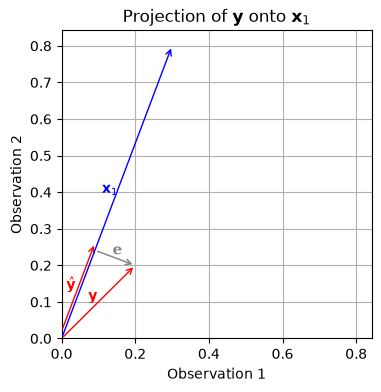

In [2]:
x_1 = np.array([0.3, 0.8])
y = np.array([0.2, 0.2])

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_projection_2d(x_1, y, ax)
plt.show()

:::{note}
- There are **two** observations of a **single** independent variable. This is $\mathbf{x}_1$.
- There are **two** observations of a **single** dependent variable. This is $\mathbf{y}$.
:::

### Reintroducing Complexity

Let's have a look at how this setup changes when we add or remove an observation.
The next plot shows how the observations space looks like with a third observation.

:::{important} Tasks
1. How does the projection formula look like for a single observation? (Still assume $p=1$.)
2. We didn't look at the bias (also called "intercept") so far. What would including the bias change the next plot?
:::

:::{tip} Your answer
:class:dropdown
1. 
2. 
:::

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import ipywidgets as widgets
from IPython.display import display


def orthogonal_projection(X: np.ndarray, y: np.ndarray):
    try:
        return X @ np.linalg.inv(X.T @ X) @ X.T @ y
    except np.linalg.LinAlgError as e:
        print(repr(e))
        return None


def interactive_vector_rotation(X, y, n_frames=90, elev=20, start_angle=0):
    X = np.array(X)
    y = np.array(y)
    angles = np.linspace(0, 360, n_frames)
    frames = []

    y_proj = orthogonal_projection(X, y)
    if y_proj is None:
        return

    if X.shape[1] == 2:
        # plane grid in parametric form: p(s,t) = s*x1 + t*x2
        span = 1
        s = np.linspace(-span, span, 10)
        t = np.linspace(-span, span, 10)
        S, T = np.meshgrid(s, t)
        P = np.outer(S, X[:, 0]) + np.outer(T, X[:, 1])
        X_surf, Y_surf, Z_surf = P[:, 0].reshape(S.shape), P[:, 1].reshape(S.shape), P[:, 2].reshape(S.shape)

    # Pre-render frames into memory
    for angle in angles:
        fig = plt.figure(figsize=(4, 4))
        ax = fig.add_subplot(111, projection="3d")

        if X.shape[1] == 2:
            ax.plot_surface(X_surf, Y_surf, Z_surf, alpha=0.25, color="cyan", edgecolor="none", zorder=0)

        lim = 1.2 * np.max(np.abs(np.vstack([*X.T, y])))
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_zlim(-lim, lim)

        for i in range(X.shape[1]):
            ax.quiver(0, 0, 0, *X[:, i], color="b", arrow_length_ratio=0.15, linewidth=1)
        ax.quiver(0, 0, 0, *y, color="r", arrow_length_ratio=0.15, linewidth=1)
        ax.quiver(0, 0, 0, *y_proj, color="r", arrow_length_ratio=0.15, linewidth=1, linestyle="dashed")
        ax.quiver(*y_proj, *(y-y_proj), color="gray", arrow_length_ratio=0.15, linewidth=1)
        ax.view_init(elev=elev, azim=angle)
        ax.set_box_aspect([1, 1, 1])

        ax.set_axis_off()
        # custom coordinate lines
        for axis in np.eye(3):
            ax.plot([0, axis[0]], [0, axis[1]], [0, axis[2]], color="black", lw=1)
        ax.text(1.1, 0, 0, "o1")
        ax.text(0, 1.1, 0, "o2")
        ax.text(0, 0, 1.1, "o3")

        plt.tight_layout()

        buf = BytesIO()
        plt.savefig(buf, format="png")
        buf.seek(0)
        frames.append(buf.read())
        plt.close(fig)

    # Interactive display
    img_widget = widgets.Image(value=frames[(start_angle*n_frames)//360], format="png", width=600, height=600)
    slider = widgets.IntSlider(min=0, max=360 - 1, step=1, value=start_angle, description="View angle")

    def update(change):
        img_widget.value = frames[(change["new"]*n_frames)//360]

    slider.observe(update, names="value")
    display(widgets.VBox([slider, img_widget]))

In [4]:
interactive_vector_rotation(np.array([[0.3, 0.8, 0.5]]).T, [0.2, 0.2, 0.8],  start_angle=280)

We add a second vector $\mathbf{x}_2$ of observations for a new independent variable.
It is linearly independent from $\mathbf{x}_1$.

:::{important} Tasks
1. What is the cyan plane w.r.t. the blue vectors $\mathbf{x}_1$ and $\mathbf{x}_2$?
2. What is the cyan plane w.r.t. $\mathbf{X}$? (**Hint:** Check slide I-1 in the "Linear Models" slide deck.)
:::

:::{tip} Your answer
:class:dropdown
1. 
2. 
:::

In [5]:
interactive_vector_rotation(np.array([[0.8, 0.3, 0.5], [0.3, 0.8, 0.5]]).T, [0.2, 0.2, 0.8],  start_angle=280)

The next code cell tries to create the same plot for two different vectors $\mathbf{x}_1$ and $\mathbf{x}_2$, but fails.

:::{important} Tasks
1. The following code breaks at the moment when the projection formula is computed. Why? (**Hint:** What is $(\mathbf{X}^T\mathbf{X})^{-1}$ in this case?)
:::

:::{tip} Your answer
:class:dropdown
1. 
:::

In [6]:
interactive_vector_rotation(np.array([[0.5, 0.5, 0.5], [1, 1, 1]]).T, [0.2, 0.2, 0.8],  start_angle=280)

LinAlgError('Singular matrix')


We add a third vector $\mathbf{x}_3$ of observations for a new independent variable.
It is linearly independent from $\mathbf{x}_1$ and $\mathbf{x}_2$.

:::{important} Tasks
1. How would the analogue of the cyan plane from before look like here?
2. Why is the projection $\hat{\mathbf{y}}$ of $\mathbf{y}$ not visible in this figure?
3. When would the projection $\hat{\mathbf{y}}$ of $\mathbf{y}$ not be visible in general?
:::

:::{tip} Your answer
:class:dropdown
1. 
2. 
3. 
:::

In [7]:
interactive_vector_rotation(np.array([[0.8, 0.3, 0.5], [0.3, 0.8, 0.5], [-0.3, -0.7, 0.5]]).T, [0.2, 0.2, 0.8],  start_angle=280)